In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI_EWaste_Project/archive (2).zip"
extract_path = "/content/ewaste_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['modified-dataset']


In [ ]:
import os

for root, dirs, files in os.walk("/content/ewaste_dataset"):
    level = root.replace("/content/ewaste_dataset", "").count(os.sep)
    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

ewaste_dataset/
  modified-dataset/
    test/
    train/
    val/


In [ ]:
import os

dataset_path = "/content/ewaste_dataset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

ewaste_dataset/
  modified-dataset/
    test/
    train/
    val/


In [ ]:
import os

train_path = None

for root, dirs, files in os.walk("/content/ewaste_dataset"):
    if os.path.basename(root).lower() == "train":
        train_path = root
        break

print("Train folder:", train_path)

Train folder: /content/ewaste_dataset/modified-dataset/train


In [ ]:
classes = sorted([
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

print("Classes:")
for i, cls in enumerate(classes):
    print(i, "→", cls)

print("\nTotal classes:", len(classes))

Classes:
0 → Battery
1 → Keyboard
2 → Microwave
3 → Mobile
4 → Mouse
5 → PCB
6 → Player
7 → Printer
8 → Television
9 → Washing Machine

Total classes: 10


In [ ]:
for cls in classes:
    folder = os.path.join(train_path, cls)
    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    print(f"{cls}: {len(images)} images")

Battery: 240 images
Keyboard: 240 images
Microwave: 240 images
Mobile: 240 images
Mouse: 240 images
PCB: 240 images
Player: 240 images
Printer: 240 images
Television: 240 images
Washing Machine: 240 images


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
import os

# Your dataset folders
train_dir = train_path

val_dir = None
test_dir = None

for root, dirs, files in os.walk("/content/ewaste_dataset"):
    folder_name = os.path.basename(root).lower()

    if folder_name == "val":
        val_dir = root

    elif folder_name == "test":
        test_dir = root

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Train: /content/ewaste_dataset/modified-dataset/train
Validation: /content/ewaste_dataset/modified-dataset/val
Test: /content/ewaste_dataset/modified-dataset/test


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 2400 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Found 300 files belonging to 10 classes.


In [ ]:
print(train_ds.class_names)

['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Number of classes
NUM_CLASSES = 10

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Load pretrained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

# Build our classifier
model = models.Sequential([
    data_augmentation,

    layers.Rescaling(
        1./127.5,
        offset=-1
    ),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Datasets prepared.")

Datasets prepared.


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 96ms/step - accuracy: 0.6508 - loss: 1.1016 - val_accuracy: 0.9200 - val_loss: 0.3556
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.8633 - loss: 0.4351 - val_accuracy: 0.9500 - val_loss: 0.2223
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.8950 - loss: 0.3304 - val_accuracy: 0.9567 - val_loss: 0.1814
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9187 - loss: 0.2578 - val_accuracy: 0.9600 - val_loss: 0.1601
Epoch 5/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.9262 - loss: 0.2317 - val_accuracy: 0.9700 - val_loss: 0.1451
Epoch 6/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9329 - loss: 0.2119 - val_accuracy: 0.9633 - val_loss: 0.1394
Epoch 7/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9417 - loss: 0.1944 - val_accuracy: 0.9733 - val_loss: 0.1397
Epoch 8/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.9362 - loss: 0.1878 - val_accuracy: 0.9667 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9500 - loss: 0.1368
Test Loss: 0.1368434876203537
Test Accuracy: 0.949999988079071
Test Accuracy (%): 94.9999988079071


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


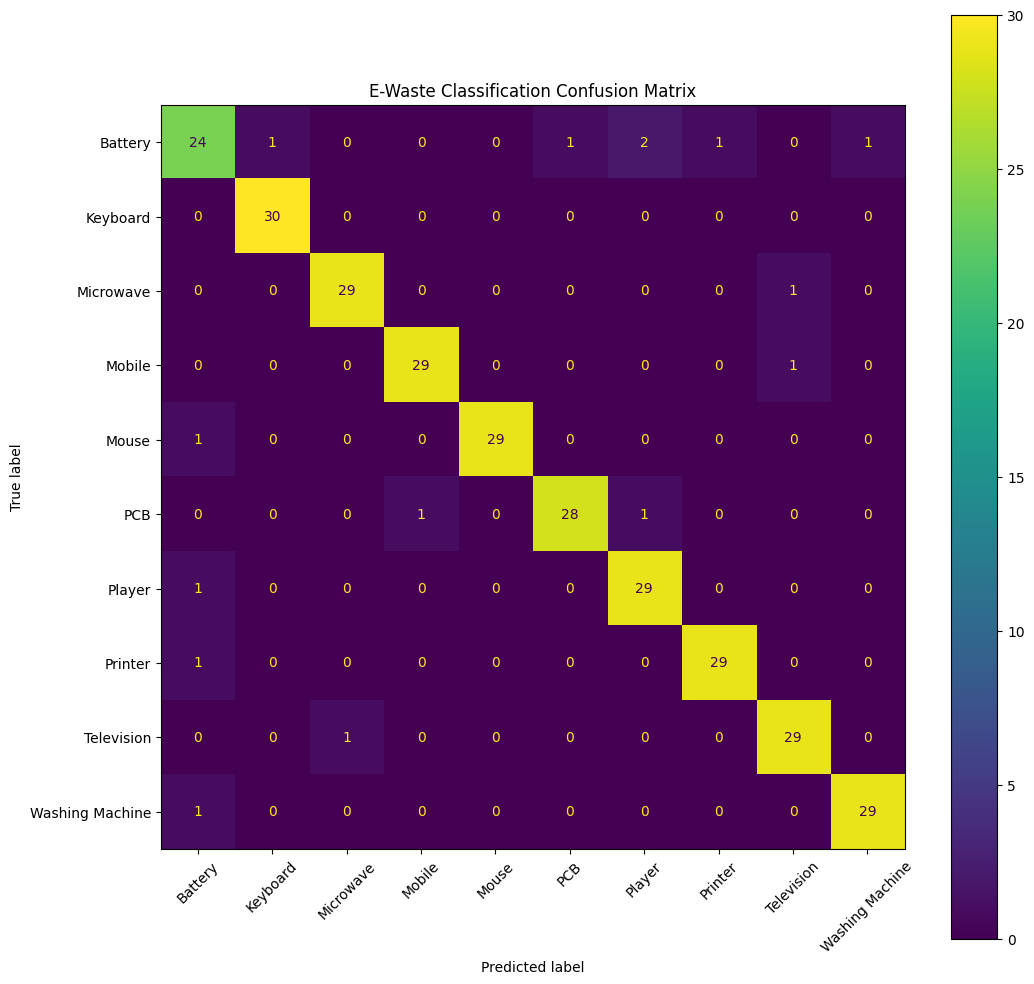

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Class names
class_names = [
    "Battery",
    "Keyboard",
    "Microwave",
    "Mobile",
    "Mouse",
    "PCB",
    "Player",
    "Printer",
    "Television",
    "Washing Machine"
]

# Get actual labels
y_true = np.concatenate([
    y.numpy() for x, y in test_ds
])

# Get model predictions
y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("E-Waste Classification Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                 precision    recall  f1-score   support

        Battery       0.86      0.80      0.83        30
       Keyboard       0.97      1.00      0.98        30
      Microwave       0.97      0.97      0.97        30
         Mobile       0.97      0.97      0.97        30
          Mouse       1.00      0.97      0.98        30
            PCB       0.97      0.93      0.95        30
         Player       0.91      0.97      0.94        30
        Printer       0.97      0.97      0.97        30
     Television       0.94      0.97      0.95        30
Washing Machine       0.97      0.97      0.97        30

       accuracy                           0.95       300
      macro avg       0.95      0.95      0.95       300
   weighted avg       0.95      0.95      0.95       300



In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Accuracy:", test_accuracy * 100, "%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9500 - loss: 0.1368
Test Accuracy: 94.9999988079071 %


In [ ]:
import os
import random

# Pick a random class
selected_class = random.choice(class_names)

# Get images from that class
class_folder = os.path.join(test_dir, selected_class)

image_files = [
    f for f in os.listdir(class_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

selected_image = random.choice(image_files)

image_path = os.path.join(class_folder, selected_image)

print("Actual class:", selected_class)
print("Image:", image_path)

Actual class: PCB
Image: /content/ewaste_dataset/modified-dataset/test/PCB/pcb_190.jpg


In [ ]:
import tensorflow as tf
import numpy as np

# Load image
img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

# Convert to array
img_array = tf.keras.utils.img_to_array(img)

# Add batch dimension
img_array = tf.expand_dims(img_array, 0)

# Prediction
predictions = model.predict(img_array, verbose=0)

# Get highest probability
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

print("Actual class:", selected_class)
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Actual class: PCB
Predicted class: PCB
Confidence: 74.18%


In [ ]:
model.save("/content/e_waste_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open("/content/e_waste_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model created successfully!")
print("Size:", len(tflite_model) / (1024 * 1024), "MB")

Saved artifact at '/tmp/tmprkuist2y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140544491281040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491281232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491283344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491283536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491282384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491282768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491282960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491284304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491283152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491282576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140544491

In [ ]:
labels = [
    "Battery",
    "Keyboard",
    "Microwave",
    "Mobile",
    "Mouse",
    "PCB",
    "Player",
    "Printer",
    "Television",
    "Washing Machine"
]

with open("/content/labels.txt", "w") as f:
    for label in labels:
        f.write(label + "\n")

print("labels.txt created successfully!")

labels.txt created successfully!


In [ ]:
from google.colab import files

files.download("/content/e_waste_classifier.tflite")
files.download("/content/labels.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>